# Assignment 2: *Neuron models*

In this assignment, we will investigate the Adaptive Exponential (`AdEx`) neuron. The model was presented in the lecture, but as a reminder, it is a 2-dimensional adaptive nonlinear integrate-and-fire model. The sub-threshold dynamics is given by:

$$C_{m} \frac{dV_{m}}{dt} = -G_{\mathrm{L}} (V_{m} - E_{L}) + G_{\mathrm{L}} \Delta_{\mathrm{T}} \mathrm{exp}\left( \frac{(V_{m} - V_{\mathrm{T}})}{\Delta_{\mathrm{T}}} \right) - w + I_{\mathrm{stim}}$$

$$\tau_{w} \frac{dw}{dt} = -w + a (V_{m} - E_{L})$$

Spiking mechanism: when the membrane crosses a hard threshold $V_\text{peak}$ (note that this is not $V_{\mathrm{T}}$), the membrane is reset to $V_{\mathrm{reset}}$ and $w$ is increased by $b$ (which sets the amplitude of spike-triggered adaptation).

For the most readable explanation of this model similar to the above equation see: http://www.scholarpedia.org/article/Adaptive_exponential_integrate-and-fire_model

We will provide an initial set of parameters below.

### General tip: 
Throughout be very careful with the units and magnitudes of variables. 
We recommend plotting the voltages in mV (so for plotting multiply all voltages by 1e3), and plotting the adaptation currents in pA (so for plotting multiply all w by 1e12). This makes it easier to compare with most literature. You could also simulate your model in mV and pA with appropriate parameter adjustments.

In [41]:
import numpy as np
import matplotlib.pyplot as plt

In [42]:
G_L = 2.*1e-9          # [nS] Leak conductance
tau_m = 20*1e-3 # slightly adjusted from original set to get irregular-like behavior
C_m = G_L*tau_m        # [pF] Membrane capacitance
E_L = -70.*1e-3         # [mV] Resting Membrane Potential
V_reset = -51.*1e-3     # [mV] Reset potential
V_peak = 0.0*1e-3       # [mV] Voltage cutoff (effective threshold)
V_th = -50.*1e-3        # [mV] Threshold
I_e = 65.0*1e-12      # [pA] Input current (constant bias)
tau_w = 100.*1e-3       # [s] adaptation time constant
Delta_T = 2.*1e-3       # [mV] Sharpness of spike initiation
a = 0.5*1e-9             # [nS] sub-threshold adaptation
b = 7.0*1e-12          # [pA] spike-triggered adapation
pars = [C_m, G_L, E_L, V_reset, V_peak, V_th, I_e, tau_w, Delta_T, a, b]

### 1. Model implementation and testing.
**(2 Points total)**

In this exercise, you will implement the AdEx neuron model and run a test simulation driving the neuron with constant current inputs.


#### 1.1. Numerical integration.

Using Euler integration, implement the model and simulate it using the default parameters provided above. This will be similar to the simulations from the first assignment, but require the addition of a voltage reset and adaptation update. It is highly recommended to make a re-usable function here, so you can easily run the model with different parameter sets later.

For this simulation, drive the neuron with a constant input current $I_{e}=500 \mathrm{pA}$ for $200 \mathrm{ms}$ and plot the resulting voltage and adaptation variable. Your solution should be similar to slide 41 from the lecture, although the spiking behavior will be different (note that for plotting purposes I there cut-off all the spikes at -30 mV).  **(1 points)**

In [43]:
def adex_sim(I_e, T=0.2, dt=1e-4,
             C_m=G_L*tau_m, G_L=G_L, E_L=E_L,
             V_reset=V_reset, V_peak=V_peak, V_th=V_th,
             tau_w=tau_w, Delta_T=Delta_T, a=a, b=b):
    steps = int(T/dt)
    V = E_L #initialize, no input yet so its at rest
    w = 0.0 #wiithout input w is 0
    V_record = np.zeros(steps)
    w_record = np.zeros(steps)
    time = np.arange(0, T, dt)
    spike_count = 0

    for i in range(steps):
        #formulas translated
        dVdt = (-G_L*(V-E_L) + G_L*Delta_T*np.exp((V-V_th)/Delta_T)-w + I_e)/C_m
        dwdt = (-w + a*(V-E_L))/tau_w

        #using Euler
        V = V + dt*dVdt
        w = w + dt*dwdt

        if V >= V_peak:
            V = V_reset #bring back down voltage once you spike
            w = w + b #after you spike adaptation gets a bump up
            spike_count += 1

        V_record[i] = V
        w_record[i] = w

        firing_rate = spike_count / T

    return time, V_record, w_record, firing_rate


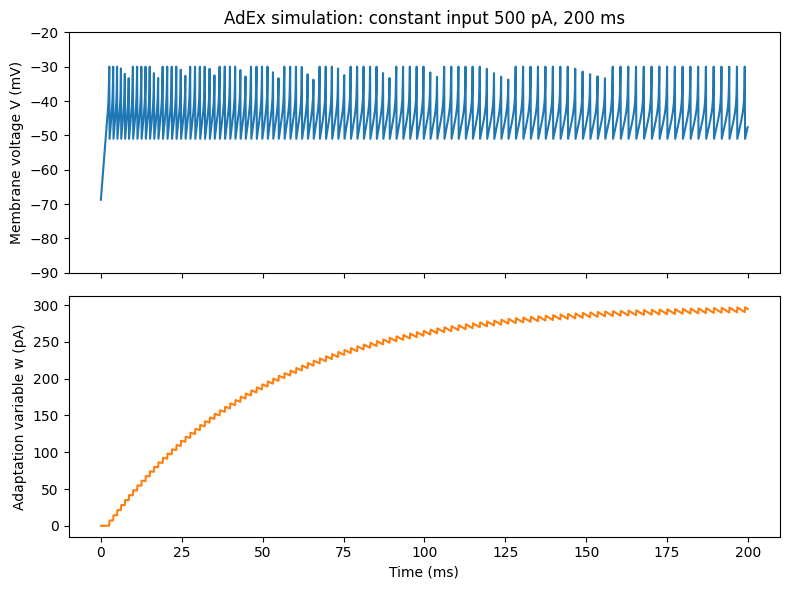

In [44]:
I_e=500e-12 #running it with 500 iimpulse
time_o, V_record_o, w_record_o, firing_rate_o = adex_sim(I_e, T=0.2, dt=1e-4)


# Calculate F-I
currents = np.linspace(0, 500e-12, 100)  # 0 to 500 pA
firing_rates_original = []

for I in currents:
    time, V_record, w_record, fr = adex_sim(I, T=0.5, dt=1e-4)
    firing_rates_original.append(fr)

# For plotting: cut off spikes at -30 mV as mentioned in the assign, to visualize better
V_plot = np.copy(V_record_o)
V_plot[V_plot > -30e-3] = -30e-3

#plottings
fig, ax = plt.subplots(2, 1, figsize=(8,6), sharex=True)

ax[0].plot(time_o*1e3, V_plot*1e3, color="tab:blue")
ax[0].set_ylabel("Membrane voltage V (mV)")
ax[0].set_title("AdEx simulation: constant input 500 pA, 200 ms")
ax[0].set_ylim([-90, -20])

ax[1].plot(time_o*1e3, w_record_o*1e12, color="tab:orange")
ax[1].set_ylabel("Adaptation variable w (pA)")
ax[1].set_xlabel("Time (ms)")

plt.tight_layout()
plt.show()



#### 1.2. Firing patterns.

**1.2.1.** Consider the different types of firing patterns described here: Fig. 6.2 at https://neuronaldynamics.epfl.ch/online/Ch6.S1.html. How would you label the firing pattern you observe, and why? Can you explain from the $V$ and $m$ time-courses why the pattern is as it is?  **(0.25 points)**

The firing pattern looks like a regular-adaptive one. Adaptive because in the paramenters we used a and b are non-zero, the adaptive variable increases gradually until it reaches a stable point by small incrreases after each spike. this causes a higher rate of spiking  when it's still low and doesn't suppress as much, then the firing rate slows down a bit and stabilizes.

**1.2.2.** Specify additional parameter sets that correspond to different firing behaviors (consult [this table](https://neuronaldynamics.epfl.ch/online/Ch6.S2.html)). Note that $\tau_m$ is given by $\frac{C_m}{G_L}$. Implement at least two different parameter sets, run the model and plot the states as above. Also note that the irregular pattern can be hard to reproduce, as the model operates in a chaotic regime and relies on very specific simulation settings (integration method and timestep).  **(0.75 points)**

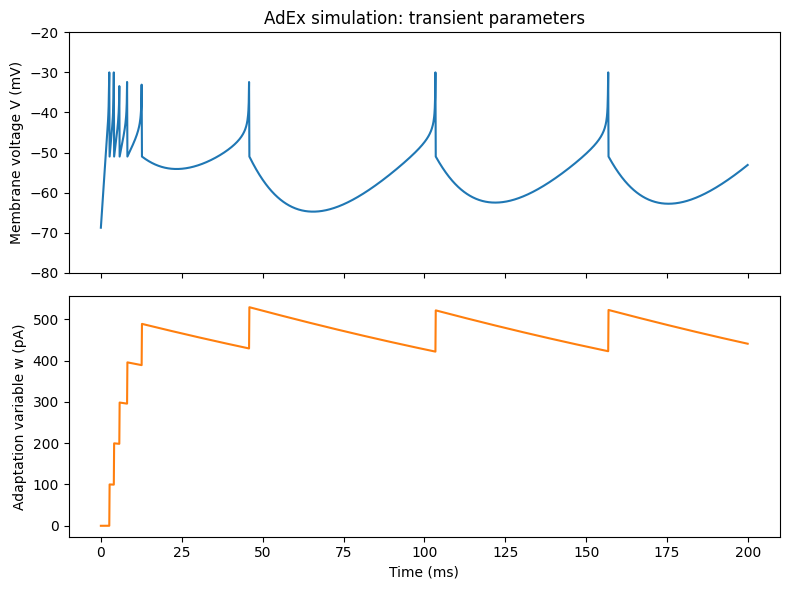

In [45]:
# Transient
tau_w_transient = 250e-3
Delta_T_transient = 2e-3
a_transient = 0.5e-9
b_transient = 100e-12
tau_m_transient = 20e-3
C_m_transient = G_L * tau_m_transient

#have to specify them all again or risk using old ones
time_t, V_record_t, w_record_t, firing_rate_t = adex_sim(
    I_e=I_e,
    T=0.2,
    dt=1e-4,
    tau_w=tau_w_transient,
    Delta_T=Delta_T_transient,
    a=a_transient,
    b=b_transient,
    C_m=C_m_transient
)

firing_rates_transient = []

for I in currents:
    time, V_record, w_record, fr = adex_sim(
        I_e=I,
        T=0.5,
        dt=1e-4,
        tau_w=tau_w_transient,
        Delta_T=Delta_T_transient,
        a=a_transient,
        b=b_transient,
    )
    firing_rates_transient.append(fr)


V_plot_t = np.copy(V_record_t)
V_plot_t[V_plot_t > -30e-3] = -30e-3

fig, ax = plt.subplots(2, 1, figsize=(8,6), sharex=True)

ax[0].plot(time_t*1e3, V_plot_t*1e3, color="tab:blue")  # Use time_t here
ax[0].set_ylabel("Membrane voltage V (mV)")
ax[0].set_title("AdEx simulation: transient parameters")
ax[0].set_ylim([-80, -20])

ax[1].plot(time_t*1e3, w_record_t*1e12, color="tab:orange")  # Use time_t here
ax[1].set_ylabel("Adaptation variable w (pA)")
ax[1].set_xlabel("Time (ms)")

plt.tight_layout()
plt.show()


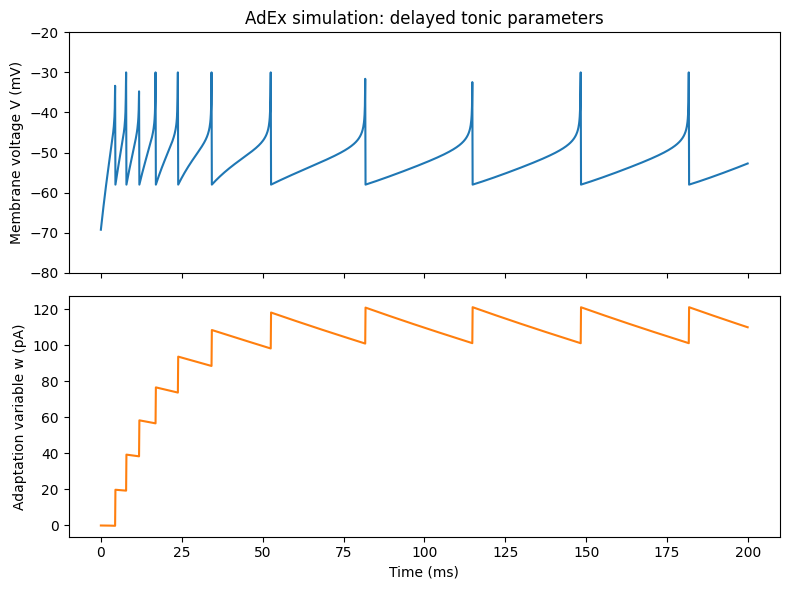

In [46]:
# Burst
I_e_burst = 150e-12
tau_w_burst = 200e-3
tau_m_burst = 10e-3
Delta_T_burst = 2e-3
a_burst = -0.5e-9
b_burst = 20e-12
V_reset_burst = -58e-3
V_th_burst = -50e-3
C_m_burst = G_L * tau_m_burst

time_d, V_record_d, w_record_d, firing_rate_d = adex_sim(
    I_e=I_e_burst,
    T=0.2,
    dt=1e-4,
    tau_w=tau_w_burst,
    Delta_T=Delta_T_burst,
    a=a_burst,
    b=b_burst,
    V_reset=V_reset_burst,
    C_m=C_m_burst,
    V_th = V_th_burst
)

# F-I curve
firing_rates_delayed = []
for I in currents:
    time, V_record, w_record, fr = adex_sim(
        I_e=I,
        T=0.5,
        dt=1e-4,
        tau_w=tau_w_burst,
        Delta_T=Delta_T_burst,
        a=a_burst,
        b=b_burst,
        V_reset=V_reset_burst,
        C_m=C_m_burst,
        V_th = V_th_burst
    )
    firing_rates_delayed.append(fr)

V_plot_d = np.copy(V_record_d)
V_plot_d[V_plot_d > -30e-3] = -30e-3

fig, ax = plt.subplots(2, 1, figsize=(8,6), sharex=True)

ax[0].plot(time_d*1e3, V_plot_d*1e3, color="tab:blue")  # Use time_d here
ax[0].set_ylabel("Membrane voltage V (mV)")
ax[0].set_title("AdEx simulation: delayed tonic parameters")
ax[0].set_ylim([-80, -20])

ax[1].plot(time_d*1e3, w_record_d*1e12, color="tab:orange")  # Use time_d here
ax[1].set_ylabel("Adaptation variable w (pA)")
ax[1].set_xlabel("Time (ms)")

plt.tight_layout()
plt.show()

## 2. Input-output functions
**(1.5 Points total)**


The frequency-current curve (fI curve or F-I curve) is a function that relates the total input current onto a neuron (I) to its firing rate (F).

**2.1.** Simulate the neuron's responses to at least 4 input currents of increasing amplitudes from 0pA to 500pA. Show how the spiking behavior changes for different amplitudes. **(0.5 points)**

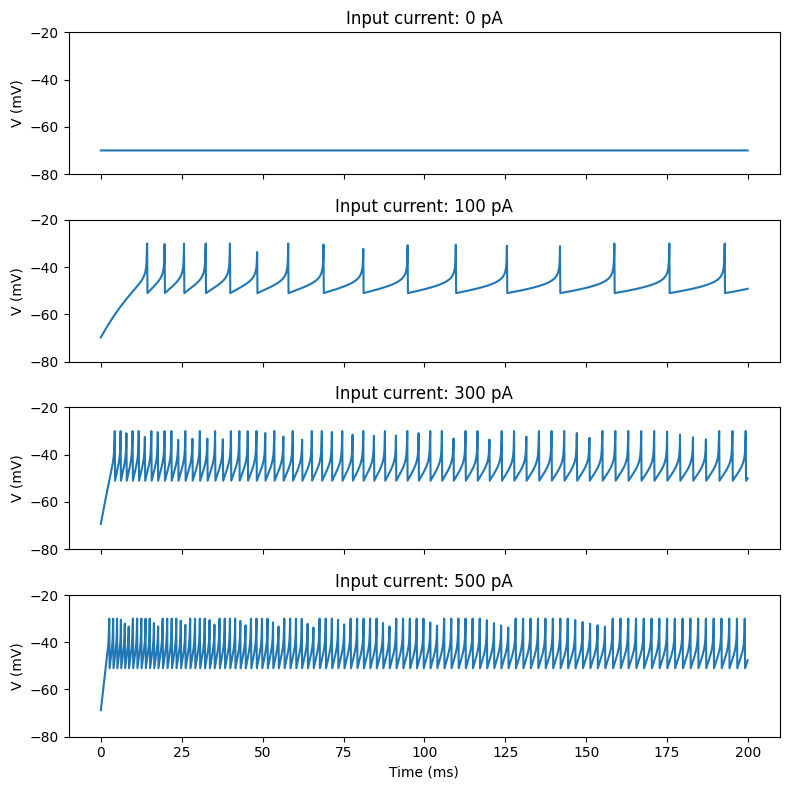

In [47]:
I_values = [0e-12, 100e-12, 300e-12, 500e-12]  # 0, 100, 300, 500 pA
T = 0.2
fig, axes = plt.subplots(len(I_values), 1, figsize=(8, 8), sharex=True)

for idx, I_e in enumerate(I_values):
    time, V_record, w_record, firing_rate = adex_sim(I_e=I_e, T=T, dt=1e-4)

    V_plot = np.copy(V_record)
    V_plot[V_plot > -30e-3] = -30e-3

    axes[idx].plot(time*1e3, V_plot*1e3, color="tab:blue")
    axes[idx].set_ylabel("V (mV)")
    axes[idx].set_ylim([-80, -20])
    axes[idx].set_title(f"Input current: {I_e*1e12:.0f} pA")

axes[-1].set_xlabel("Time (ms)")
plt.tight_layout()
plt.show()

**2.1.** Calculate the F-I curve by considering 100 input current magnitudes ranging from 0pA to 500pA.

Plot the fI-curve for the 3 parameter sets that you have defined above (the one provided and the two you chose in 1.2.2.). **(1 points)**

You can calculate the firing rate as the number of spikes per second while the current is on. Run the current for half a second, at different magnitudes.

I recommend to run a separate simulation for each current magnitude and record the firing rate.

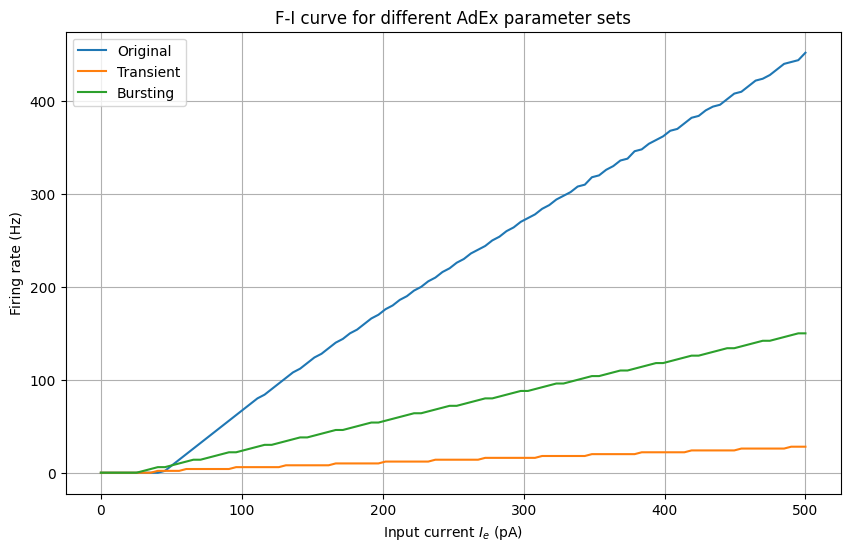

In [48]:
plt.figure(figsize=(10, 6))
plt.plot(currents*1e12, firing_rates_original, label="Original", color="tab:blue")
plt.plot(currents*1e12, firing_rates_transient, label="Transient", color="tab:orange")
plt.plot(currents*1e12, firing_rates_delayed, label="Bursting", color="tab:green")

plt.xlabel("Input current $I_e$ (pA)")
plt.ylabel("Firing rate (Hz)")
plt.title("F-I curve for different AdEx parameter sets")
plt.legend()
plt.grid(True)
plt.show()





## 3. Phase-plane analysis
**(2.5 Points total)**

The AdEx model is a two-dimensional nonlinear dynamical system. A phase-plane diagram allows us to understand the model's behavior by studying the displacement of its state variables with time, the location and stability of its fixed points.

**3.1.** To get an initial intuition for the system's behavior, plot the (w-V)-dynamics, i.e. instead of plotting the dynamics of the state variables with time, w(t) and V(t), plot them against each other (w-V). Do this for the initial parameter set. **(0.5 Points)**


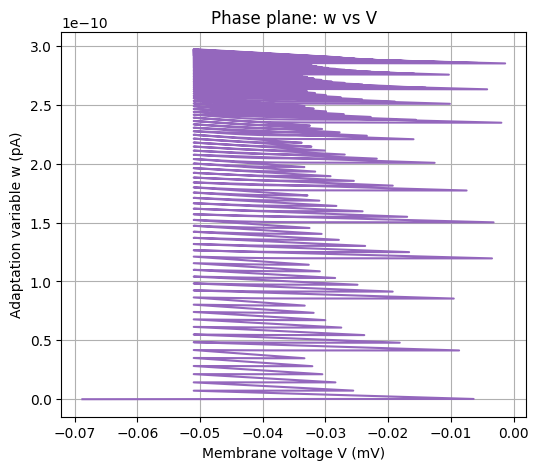

In [49]:
V_mV = V_record_o
w_pA = w_record_o

# Plot V vs w
plt.figure(figsize=(6,5))
plt.plot(V_mV, w_pA, color="tab:purple")
plt.xlabel("Membrane voltage V (mV)")
plt.ylabel("Adaptation variable w (pA)")
plt.title("Phase plane: w vs V")
plt.grid(True)
plt.show()
#does not look like the slides, but im not sure where the issue is


**3.2.** Write an expression for the V and w nullclines and plot them in the (V, w) phase plane in the absence of input current, $I(t)=0$. Your solution should be similar to slide 42 of the lecture (although not completely the same as the parameter set is different). **(0.5 Points)**

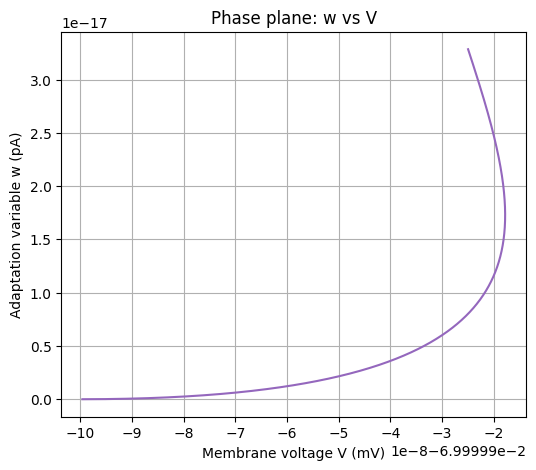

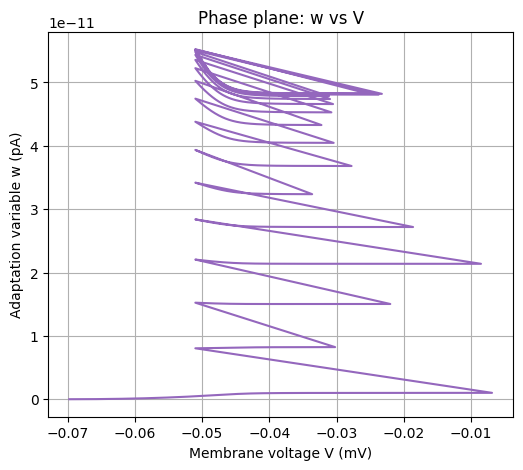

In [63]:
I_e = 0
time, V_record, w_record, firing_rate = adex_sim(I_e, T=0.2, dt=1e-4)

# Plot V vs w
plt.figure(figsize=(6,5))
plt.plot(V_record, w_record, color="tab:purple")
plt.xlabel("Membrane voltage V (mV)")
plt.ylabel("Adaptation variable w (pA)")
plt.title("Phase plane: w vs V")
plt.grid(True)
plt.show()


I_e = 100e-12
time, V_record, w_record, firing_rate = adex_sim(I_e, T=0.2, dt=1e-4)

# Plot V vs w
plt.figure(figsize=(6,5))
plt.plot(V_record, w_record, color="tab:purple")
plt.xlabel("Membrane voltage V (mV)")
plt.ylabel("Adaptation variable w (pA)")
plt.title("Phase plane: w vs V")
plt.grid(True)
plt.show()
#this second one looks more like the examples in the slides, but for some reason in later visualizations i cannot get it to show correctly

![](https://drive.google.com/uc?id=1MK66-8Rw6jt3DypX9ZgCp6yNAnr5_Uin)

**3.3.** How do the nullclines change with respect to the sub-threshold adaptation parameter $a$ and applied current $I_\text{stim}$? Plot some examples and describe. **(0.5 Points)**
If you increase a it changes the inclination of the line (gets steeper the higher a is), this makes sence since a higher a in the equation equals to a faster rate of change for w. Increasing I means that at every V you need a higher w to drag the spike back down, so the entire curve gets shifted upwards.

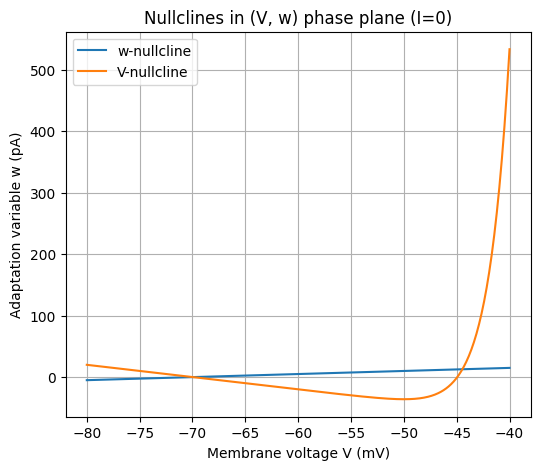

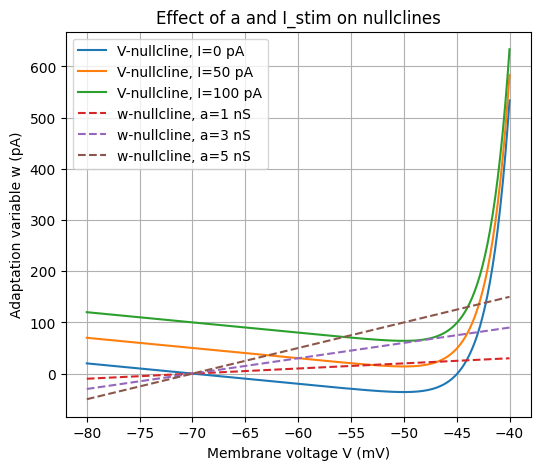

In [51]:
V = np.linspace(-80e-3, -40e-3, 500)
I_e = 0

# Nullclines
w_null = a * (V - E_L)
V_null = -G_L * (V - E_L) +G_L * Delta_T * np.exp((V - V_th) / Delta_T) + I_e

# Plot with all the right unit fpr measurements
plt.figure(figsize=(6,5))
plt.plot(V*1e3, w_null*1e12, label="w-nullcline", color="tab:blue")
plt.plot(V*1e3, V_null*1e12, label="V-nullcline", color="tab:orange")
plt.xlabel("Membrane voltage V (mV)")
plt.ylabel("Adaptation variable w (pA)")
plt.title("Nullclines in (V, w) phase plane (I=0)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6,5))

# testing v-nulls with different Inputs
for I_e in [0, 50e-12, 100e-12]:  # 0, 50 pA, 100 pA
    V_null = -G_L * (V - E_L) + G_L * Delta_T * np.exp((V - V_th)/Delta_T) + I_e
    plt.plot(V*1e3, V_null*1e12, label=f"V-nullcline, I={I_e*1e12:.0f} pA")

# testing wnulls with different as
for a_test in [1e-9, 3e-9, 5e-9]:  # 1, 3, 5 nS
    w_null = a_test * (V - E_L)
    plt.plot(V*1e3, w_null*1e12, '--', label=f"w-nullcline, a={a_test*1e9:.0f} nS")

plt.xlabel("Membrane voltage V (mV)")
plt.ylabel("Adaptation variable w (pA)")
plt.title("Effect of a and I_stim on nullclines")
plt.legend()
plt.grid(True)
plt.show()



**3.4.** For the initial parameter set, plot the w-V curve on top of the nullclines for one spike, and then for several spikes (e.g., if the spiking behavior is 'tonic', explain why it is so). Explain the spiking behavior using this. This analysis should be similar to slides 43 and 44 from the lecture. **(1 Points)**

Theoretically for one spike the trajectory should loop once, leaving the equilibrium then as the adaptation curve rises it should get pulled back towards that same origin. Whilie for the tonic spiking you should get repeated cycles around nullclines, forming what is called a limit cycle because it doesn't come back to rest fully, it does periodic orbits that correspond to sustained rythmic spiking.

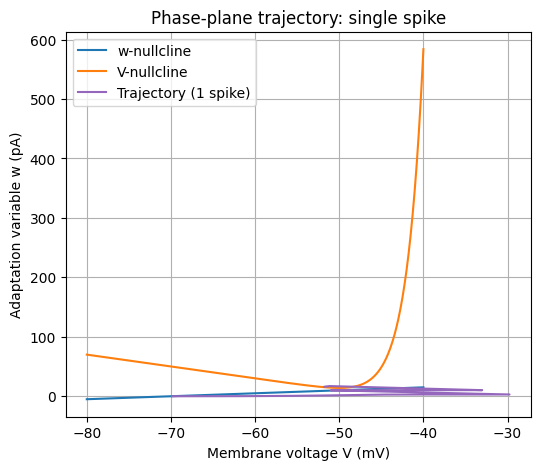

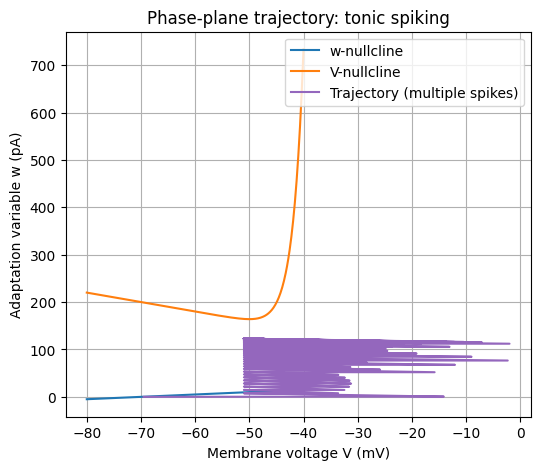

In [62]:
def plot_nullclines(ax, I_e):
    w_null = a * (V - E_L)
    V_null = -G_L * (V - E_L) + G_L * Delta_T * np.exp((V - V_th)/Delta_T) + I_e
    ax.plot(V*1e3, w_null*1e12, label="w-nullcline", color="tab:blue")
    ax.plot(V*1e3, V_null*1e12, label="V-nullcline", color="tab:orange")

I_e = 50e-12   # current just strong enough for one spike
time, V_record, w_record, _ = adex_sim(I_e, T=0.1, dt=1e-4)

fig, ax = plt.subplots(figsize=(6,5))
plot_nullclines(ax, I_e)
ax.plot(V_record*1e3, w_record*1e12, color="tab:purple", label="Trajectory (1 spike)")
ax.set_xlabel("Membrane voltage V (mV)")
ax.set_ylabel("Adaptation variable w (pA)")
ax.set_title("Phase-plane trajectory: single spike")
ax.legend()
ax.grid(True)
plt.show()

I_e = 200e-12   # larger current should have multiple spikes
time, V_record, w_record, _ = adex_sim(I_e, T=0.5, dt=1e-4)

fig, ax = plt.subplots(figsize=(6,5))
plot_nullclines(ax, I_e)
ax.plot(V_record*1e3, w_record*1e12, color="tab:purple", label="Trajectory (multiple spikes)")
ax.set_xlabel("Membrane voltage V (mV)")
ax.set_ylabel("Adaptation variable w (pA)")
ax.set_title("Phase-plane trajectory: tonic spiking")
ax.legend()
ax.grid(True)
plt.show()
#im not sure the graphs should come out like this, but Im unsure of what to change and how, and how it should look like



**3.4 (BONUS).** Use the analysis you developped above to explain the spiking behavior of your other two chosen parameter sets. **(0.25 bonus points per parameter set explained)**

# 4 (*For background interest*) Signal encoding  with neuronal dynamics

Now that you have a solid understanding of the AdEx model and its responsiveness, take a look at the example notebook, [AdEx-encoder-example](./AdEx-encoder-example.ipynb) that demonstrates a simple use case where the complexity of the neuron's fI curve and nonlinearities are used to encode a time-dependent input signal. For those following neuromorphic engineering and/or computing this one is of particular interest.

**Note:** This part is just a curiosity, there is no evaluation involved. You won't be able to run the model in that notebook without installing Nest. We have prerun everything in the notebook so you can see the outputs without having to run Nest.
